# Pareto Front Visualization — Proposed vs Baselines

Objective space: $F_0 = -\text{Accuracy}$ (minimise), $F_1 = \text{Latency (ms)}$ (minimise).  
Step-plots trace the staircase Pareto frontier; scatter shows all evaluated architectures.

**Reference**: All JSON archives in `results/`.

# Summary :

This notebook generates publication-quality, multi-objective Pareto front visualizations. It evaluates the trade-off between Accuracy (to be maximized) and Latency (to be minimized) for a Proposed Neural Architecture Search (NAS) algorithm compared against baselines (NSGA-II and Random Search) across a 3x3 grid of dataset and hardware combinations.

### Key Techniques and Methodologies Implemented

* **Global Front Aggregation**: Rather than plotting overlapping lines for all 30 random seeds, the code pools all evaluated architectures across all seeds for each algorithm. It then calculates a single, aggregate non-dominated Pareto front to provide a clean comparison.
* **Ghost Scatter and Step Interpolation**: Raw architecture evaluations are plotted as "ghost points" with very low opacity to visualize the search space exploration. The optimal Pareto frontiers are highlighted using bold, post-interpolated step lines.
* **Smart Line Styling and Z-Ordering**: To solve visual overlap (Z-fighting) when algorithms find the exact same architectures, NSGA-II is styled as a thick dashed line with a lower z-order, while the Proposed algorithm is a solid, thinner line drawn on top. This allows the viewer to see both lines simultaneously.
* **Dynamic Axis Bounding**: The script dynamically calculates the bounding box for the highly competitive algorithms (Proposed and NSGA-II) and restricts the plot's view to this specific region. This prevents poorly performing outliers from Random Search from artificially zooming out the axes.
* **Dominated Area Shading**: A programmatic `fill_between` is applied to shade the exact region where the Proposed algorithm dominates the baseline. This visually represents the gained Hypervolume.
* **Knee Detection and Inset Zooming**: The notebook mathematically calculates the "knee" (the most optimal trade-off bend) of the Pareto front by finding the maximum perpendicular distance to the endpoints. It then generates a zoomed-in inset axis (a magnifying glass effect) at this location to highlight marginal algorithmic victories that would otherwise be invisible on the main scale.

### Libraries and Tools Used

* **Data Processing**: `numpy` for array manipulations and geometric math (using a 2D cross-product alternative to ensure compatibility with NumPy 2.0), and the built-in `json` library for loading the search archives.
* **Visualization**: `matplotlib.pyplot` for core plotting, `matplotlib.lines` for custom decoupled legends, and `mpl_toolkits.axes_grid1.inset_locator` to generate the inset zoomed axes.
* **File Management**: `pathlib` for robust, dynamic directory traversal to locate the nested multi-hardware result files and save the output grid as a PDF.

**Legend:** blue circle = Proposed, orange dashed square = NSGA-II, gray dotted triangle = Random Search.


In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    raise FileNotFoundError("Unable to locate the repository root for HW-NAS-Memetic.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.data_processing import get_project_root
assert get_project_root() == PROJECT_ROOT


import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import warnings
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from src.analysis.pareto_metrics import archive_to_points
from src.analysis.data_loader import (
    DATASETS, HARDWARE, ALGO_SPEC,
    combo_archive_sets as _combo_archive_sets, aggregate_front, focus_range,
)
from src.utils.pareto_math import find_knee_point, step_interp, seed_front, attained_latency
from src.utils import plotting_helpers as _ph
setup_matplotlib_style = getattr(_ph, "setup_matplotlib_style", None)
if setup_matplotlib_style is None:
    for _name in ("set_matplotlib_style", "setup_style", "apply_style"):
        if hasattr(_ph, _name):
            setup_matplotlib_style = getattr(_ph, _name)
            break
if setup_matplotlib_style is None:
    raise ImportError("No matplotlib style setup function found in src.utils.plotting_helpers")
setup_matplotlib_style = _ph.setup_matplotlib_style
create_grid_figure = _ph.create_grid_figure
make_algo_legend_handles = _ph.make_algo_legend_handles
save_combo_plot = _ph.save_combo_plot
style_pareto_panel = _ph.style_pareto_panel

# Backward/forward compatible resolver for the panel-drawing API
draw_combo_panel = getattr(_ph, "draw_combo_panel", None)
if draw_combo_panel is None:
    for _name in ("plot_combo_panel", "render_combo_panel", "draw_panel", "style_pareto_panel"):
        if hasattr(_ph, _name):
            draw_combo_panel = getattr(_ph, _name)
            break

if draw_combo_panel is None:
    raise ImportError(
        "No panel drawing function found in src.utils.plotting_helpers "
        "(expected draw_combo_panel or a compatible alias)."
    )

RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "figures" / "pareto_fronts"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PLOT_ORDER = ["Random Search", "NSGA-II", "Proposed"]
combo_archive_sets = functools.partial(_combo_archive_sets, RESULTS_DIR)


ALGO_STYLES = {
    "Proposed":      ("#1f77b4", "-",  "o", 2.0, 10, 1.0),
    "NSGA-II":       ("#ff7f0e", "--", "s", 3.5,  5, 0.8),
    "Random Search": ("#7f7f7f", ":",  "^", 1.5,  1, 0.6),
}

setup_matplotlib_style()




In [2]:
# ── All data-loading helpers now live in src/analysis/data_loader.py ─────────
# Imported in cell 1:
#   combo_archive_sets(dataset, hardware)  → {algo: [seed_archive, ...]}
#   aggregate_front(archives)              → (N, 2) global Pareto front
#   focus_range(sets)                      → (x_lo, x_hi, y_hi)
#
# ── All Pareto math helpers now live in src/utils/pareto_math.py ─────────────
# Imported in cell 1:
#   find_knee(front)                       → knee-point index
#   step_interp(x_pts, y_pts, x_query)    → step-interpolated y-values
#   seed_front(archive)                    → per-seed non-dominated front
#   attained_latency(front, x_grid)        → EAF attainment array

print("Helpers ready (all imported from src/).")


Helpers ready (all imported from src/).


Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/cifar10/edgegpu_latency/pareto.pdf
Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/cifar10/raspi4_latency/pareto.pdf
Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/cifar10/eyeriss_latency/pareto.pdf
Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/cifar100/edgegpu_latency/pareto.pdf
Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/cifar100/raspi4_latency/pareto.pdf
Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/cifar100/eyeriss_latency/pareto.pdf
Saved individual plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/ImageNet16-120/edgegpu_latency/pareto.pdf
Saved individual pl

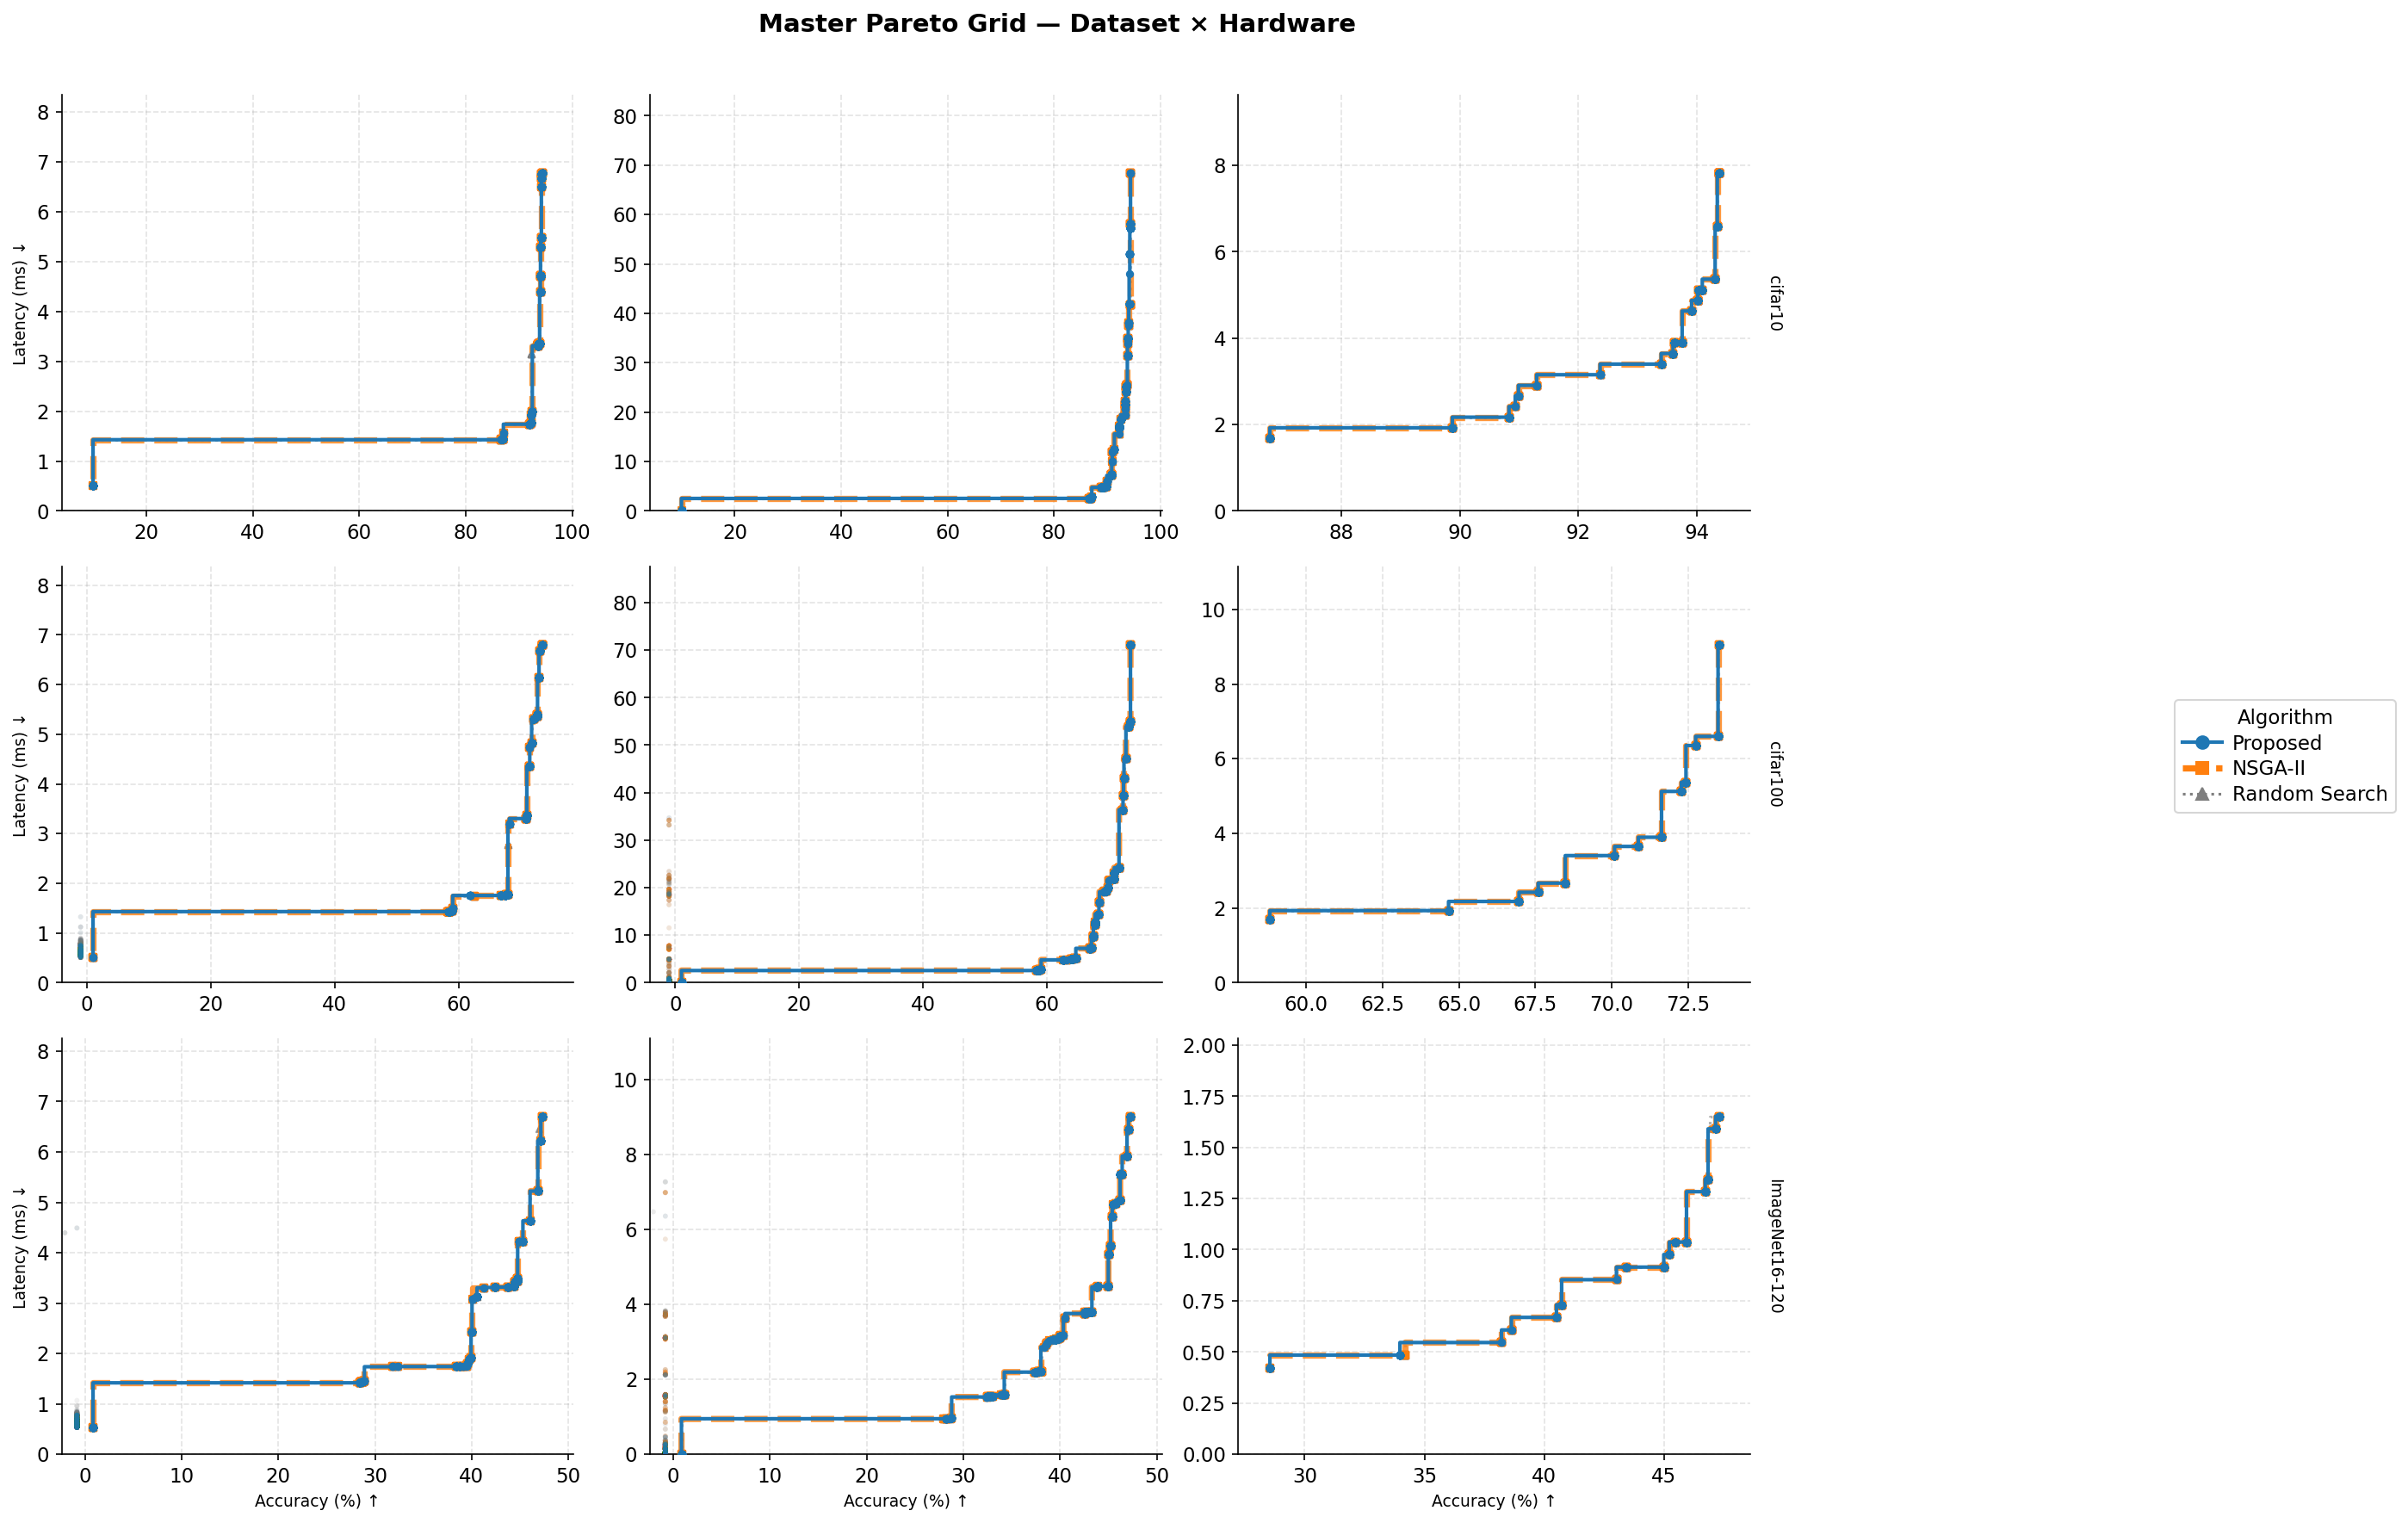

Saved master grid → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/pareto_master_grid.pdf
Saved 9 individual plots.


In [3]:
plt.close('all')
master_fig, master_axes = create_grid_figure(len(DATASETS), len(HARDWARE), figsize=(5.5 * len(HARDWARE), 4 * len(DATASETS)))
saved = 0

for row_idx, dataset in enumerate(DATASETS):
    for col_idx, hardware in enumerate(HARDWARE):
        ax = master_axes[row_idx][col_idx]
        sets = combo_archive_sets(dataset, hardware)

        if all(len(v) == 0 for v in sets.values()):
            ax.text(
                0.5, 0.5, f"No data\n{dataset}/{hardware}",
                ha="center", va="center", transform=ax.transAxes, color="grey"
            )
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        saved += save_combo_plot(
            dataset,
            hardware,
            sets,
            aggregate_front,
            focus_range,
            archive_to_points,
            RESULTS_DIR,
            PLOTS_DIR,
            PLOT_ORDER,
            ALGO_STYLES,
            step_interp,
            find_knee_point,
        )

        panel_out = None
        if draw_combo_panel is not None:
            try:
                panel_out = draw_combo_panel(
                    ax=ax,
                    dataset=dataset,
                    hardware=hardware,
                    sets=sets,
                    aggregate_front=aggregate_front,
                    focus_range=focus_range,
                    archive_to_points=archive_to_points,
                    plot_order=PLOT_ORDER,
                    algo_styles=ALGO_STYLES,
                    step_interp=step_interp,
                    find_knee_point=find_knee_point,
                )
            except TypeError:
                try:
                    panel_out = draw_combo_panel(ax, dataset, hardware, sets)
                except TypeError:
                    panel_out = None

        if panel_out is None:
            x_lo, x_hi, y_hi = focus_range(sets)
            for algo in PLOT_ORDER:
                archives = sets.get(algo, [])
                if not archives:
                    continue

                color, ls, mk, lw, zo, al = ALGO_STYLES[algo]
                for archive in archives:
                    pts = archive_to_points(archive)
                    if len(pts):
                        ax.scatter(
                            pts[:, 0], pts[:, 1],
                            s=8, color=color, alpha=0.05,
                            edgecolors="none", zorder=max(1, zo - 3),
                        )

                front = aggregate_front(archives)
                if len(front):
                    ax.step(
                        front[:, 0], front[:, 1], where="post",
                        color=color, linestyle=ls, linewidth=lw, alpha=al, zorder=zo,
                    )
                    ax.scatter(
                        front[:, 0], front[:, 1],
                        s=12, color=color, marker=mk,
                        alpha=min(1.0, al + 0.15), zorder=zo + 0.1,
                    )

            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(0, max(1.0, y_hi * 1.08))
            ax.grid(True, linestyle="--", alpha=0.35)
        elif isinstance(panel_out, tuple) and len(panel_out) >= 4:
            _, x_lo, x_hi, y_hi = panel_out
        else:
            x_lo, x_hi, y_hi = focus_range(sets)

        if row_idx == len(DATASETS) - 1:
            ax.set_xlabel("Accuracy (%) ↑", fontsize=9)
        if col_idx == 0:
            ax.set_ylabel("Latency (ms) ↓", fontsize=9)
        if col_idx == len(HARDWARE) - 1:
            ax.annotate(dataset, xy=(1.03, 0.5), xycoords='axes fraction',
                        rotation=-90, ha='left', va='center', fontsize=9)

legend_handles = make_algo_legend_handles(ALGO_STYLES, ["Proposed", "NSGA-II", "Random Search"])
master_fig.legend(handles=legend_handles, title="Algorithm", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=11, title_fontsize=11, labelspacing=0.3, handletextpad=0.5)
master_fig.suptitle("Master Pareto Grid — Dataset × Hardware", fontsize=14, fontweight='bold')
master_fig.tight_layout(rect=[0, 0, 0.85, 0.97])
master_out = PLOTS_DIR / "pareto_master_grid.pdf"
master_fig.savefig(master_out, bbox_inches='tight', dpi=200)
plt.show()
print(f"Saved master grid → {master_out}")
print(f"Saved {saved} individual plots.")


In [4]:
from importlib import import_module

_report_generators = import_module("src.analysis.report_generators")

generate_genotype_catalog = None
for candidate in (
    "generate_genotype_catalog",
    "create_genotype_catalog",
    "build_genotype_catalog",
    "write_genotype_catalog",
    "export_genotype_catalog",
):
    if hasattr(_report_generators, candidate):
        generate_genotype_catalog = getattr(_report_generators, candidate)
        break

if generate_genotype_catalog is None:
    available = [
        name for name in dir(_report_generators)
        if "genotype" in name.lower() or "catalog" in name.lower()
    ]
    raise ImportError(
        "Unable to import a genotype catalog generator from src.analysis.report_generators. "
        f"Available candidates: {available}"
    )

REPORTS_DIR = RESULTS_DIR / "reports" / "pareto"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

generate_uniqueness_reports = None
for candidate in (
    "generate_uniqueness_reports",
    "create_uniqueness_reports",
    "build_uniqueness_reports",
    "write_uniqueness_reports",
    "export_uniqueness_reports",
):
    if hasattr(_report_generators, candidate):
        generate_uniqueness_reports = getattr(_report_generators, candidate)
        break

if generate_uniqueness_reports is not None:
    generate_uniqueness_reports(
        results_dir=RESULTS_DIR,
        output_dir=REPORTS_DIR,
    )
else:
    available = [
        name for name in dir(_report_generators)
        if "uniqueness" in name.lower() or "report" in name.lower()
    ]
    warnings.warn(
        "No uniqueness report generator found in src.analysis.report_generators. "
        f"Skipping uniqueness report generation. Available candidates: {available}"
    )
generate_genotype_catalog(
    results_dir=RESULTS_DIR,
    output_dir=REPORTS_DIR,
)
print(f"Saved genotype uniqueness reports and catalog → {REPORTS_DIR}")


[report_generators] Summary  → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/reports/pareto/uniqueness_summary.md
[report_generators] Detail   → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/reports/pareto/uniqueness_detail.md
[report_generators] Catalog  → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/reports/pareto/genotype_catalog.md
Saved genotype uniqueness reports and catalog → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/reports/pareto


In [5]:
from pathlib import Path
from IPython.display import Markdown, display

catalog_path = Path(REPORTS_DIR) / "genotype_catalog.md"
if not catalog_path.exists():
    raise FileNotFoundError(f"Genotype catalog not found: {catalog_path}")

catalog_text = catalog_path.read_text(encoding="utf-8")
lines = catalog_text.splitlines()
preview_lines = lines[:32]

preview_md = "\n".join(preview_lines)
if len(lines) > len(preview_lines):
    preview_md += "\n\n... (catalog truncated for notebook preview)"

display(Markdown("## Genotype Catalog Preview\n"))
display(Markdown(preview_md))

display(Markdown("<details><summary>Show full genotype catalog</summary>\n\n" + catalog_text + "\n</details>"))

## Genotype Catalog Preview


# Genotype Catalog — Fully Unique Proposed Architectures
_Generated: 2026-05-11 21:02 UTC_

This catalog records the exact architecture strings discovered by the
Proposed search that were not found by any baseline algorithm.


---

## cifar10 / Edge GPU

No fully unique Proposed architectures were found for this combination.
---

## cifar10 / Raspi4

- **Fully unique Proposed architectures**: 5
- **Structural profile:**
- **Unique architecture count**: 5
- **Total operation edges**: 30 (30 expected if all strings are valid)
- **nor_conv_3x3**: 12 (40.0% of unique op occurrences)
- **nor_conv_1x1**: 8 (26.7% of unique op occurrences)
- **skip_connect**: 6 (20.0% of unique op occurrences)
- **none**: 3 (10.0% of unique op occurrences)
- **avg_pool_3x3**: 1 (3.3% of unique op occurrences)
- **3x3 convolutions**: 12 (40.0% of ops)
- **Skip connections**: 6 (20.0% of ops)

<details><summary>Show fully unique architectures</summary>

- `[1, 4, 0, 3, 1, 3]`
- `[3, 3, 4, 1, 0, 4]`

... (catalog truncated for notebook preview)

<details><summary>Show full genotype catalog</summary>

# Genotype Catalog — Fully Unique Proposed Architectures
_Generated: 2026-05-11 21:02 UTC_

This catalog records the exact architecture strings discovered by the
Proposed search that were not found by any baseline algorithm.


---

## cifar10 / Edge GPU

No fully unique Proposed architectures were found for this combination.
---

## cifar10 / Raspi4

- **Fully unique Proposed architectures**: 5
- **Structural profile:**
- **Unique architecture count**: 5
- **Total operation edges**: 30 (30 expected if all strings are valid)
- **nor_conv_3x3**: 12 (40.0% of unique op occurrences)
- **nor_conv_1x1**: 8 (26.7% of unique op occurrences)
- **skip_connect**: 6 (20.0% of unique op occurrences)
- **none**: 3 (10.0% of unique op occurrences)
- **avg_pool_3x3**: 1 (3.3% of unique op occurrences)
- **3x3 convolutions**: 12 (40.0% of ops)
- **Skip connections**: 6 (20.0% of ops)

<details><summary>Show fully unique architectures</summary>

- `[1, 4, 0, 3, 1, 3]`
- `[3, 3, 4, 1, 0, 4]`
- `[4, 4, 0, 1, 3, 4]`
- `[4, 4, 2, 1, 4, 3]`
- `[4, 4, 4, 1, 3, 3]`
</details>
---

## cifar10 / Eyeriss

No fully unique Proposed architectures were found for this combination.
---

## cifar100 / Edge GPU

- **Fully unique Proposed architectures**: 1
- **Structural profile:**
- **Unique architecture count**: 1
- **Total operation edges**: 6 (6 expected if all strings are valid)
- **none**: 3 (50.0% of unique op occurrences)
- **skip_connect**: 1 (16.7% of unique op occurrences)
- **nor_conv_3x3**: 1 (16.7% of unique op occurrences)
- **nor_conv_1x1**: 1 (16.7% of unique op occurrences)
- **3x3 convolutions**: 1 (16.7% of ops)
- **Skip connections**: 1 (16.7% of ops)

<details><summary>Show fully unique architectures</summary>

- `[1, 4, 0, 3, 0, 0]`
</details>
---

## cifar100 / Raspi4

No fully unique Proposed architectures were found for this combination.
---

## cifar100 / Eyeriss

No fully unique Proposed architectures were found for this combination.
---

## ImageNet16-120 / Edge GPU

No fully unique Proposed architectures were found for this combination.
---

## ImageNet16-120 / Raspi4

- **Fully unique Proposed architectures**: 1
- **Structural profile:**
- **Unique architecture count**: 1
- **Total operation edges**: 6 (6 expected if all strings are valid)
- **none**: 3 (50.0% of unique op occurrences)
- **nor_conv_1x1**: 2 (33.3% of unique op occurrences)
- **nor_conv_3x3**: 1 (16.7% of unique op occurrences)
- **3x3 convolutions**: 1 (16.7% of ops)
- **Skip connections**: 0 (0.0% of ops)

<details><summary>Show fully unique architectures</summary>

- `[3, 4, 0, 3, 0, 0]`
</details>
---

## ImageNet16-120 / Eyeriss

- **Fully unique Proposed architectures**: 13
- **Structural profile:**
- **Unique architecture count**: 13
- **Total operation edges**: 78 (78 expected if all strings are valid)
- **skip_connect**: 38 (48.7% of unique op occurrences)
- **nor_conv_1x1**: 26 (33.3% of unique op occurrences)
- **none**: 14 (17.9% of unique op occurrences)
- **3x3 convolutions**: 0 (0.0% of ops)
- **Skip connections**: 38 (48.7% of ops)

<details><summary>Show fully unique architectures</summary>

- `[0, 1, 1, 1, 3, 3]`
- `[0, 1, 3, 1, 0, 3]`
- `[0, 1, 3, 1, 1, 3]`
- `[0, 1, 3, 3, 1, 1]`
- `[1, 0, 0, 1, 3, 3]`
- `[1, 1, 0, 3, 1, 3]`
- `[1, 1, 1, 1, 3, 3]`
- `[1, 1, 3, 0, 3, 1]`
- `[3, 0, 0, 1, 1, 3]`
- `[3, 1, 0, 1, 1, 3]`
- `[3, 1, 1, 0, 1, 3]`
- `[3, 1, 1, 1, 1, 3]`
- `[3, 3, 1, 1, 0, 1]`
</details>
</details>

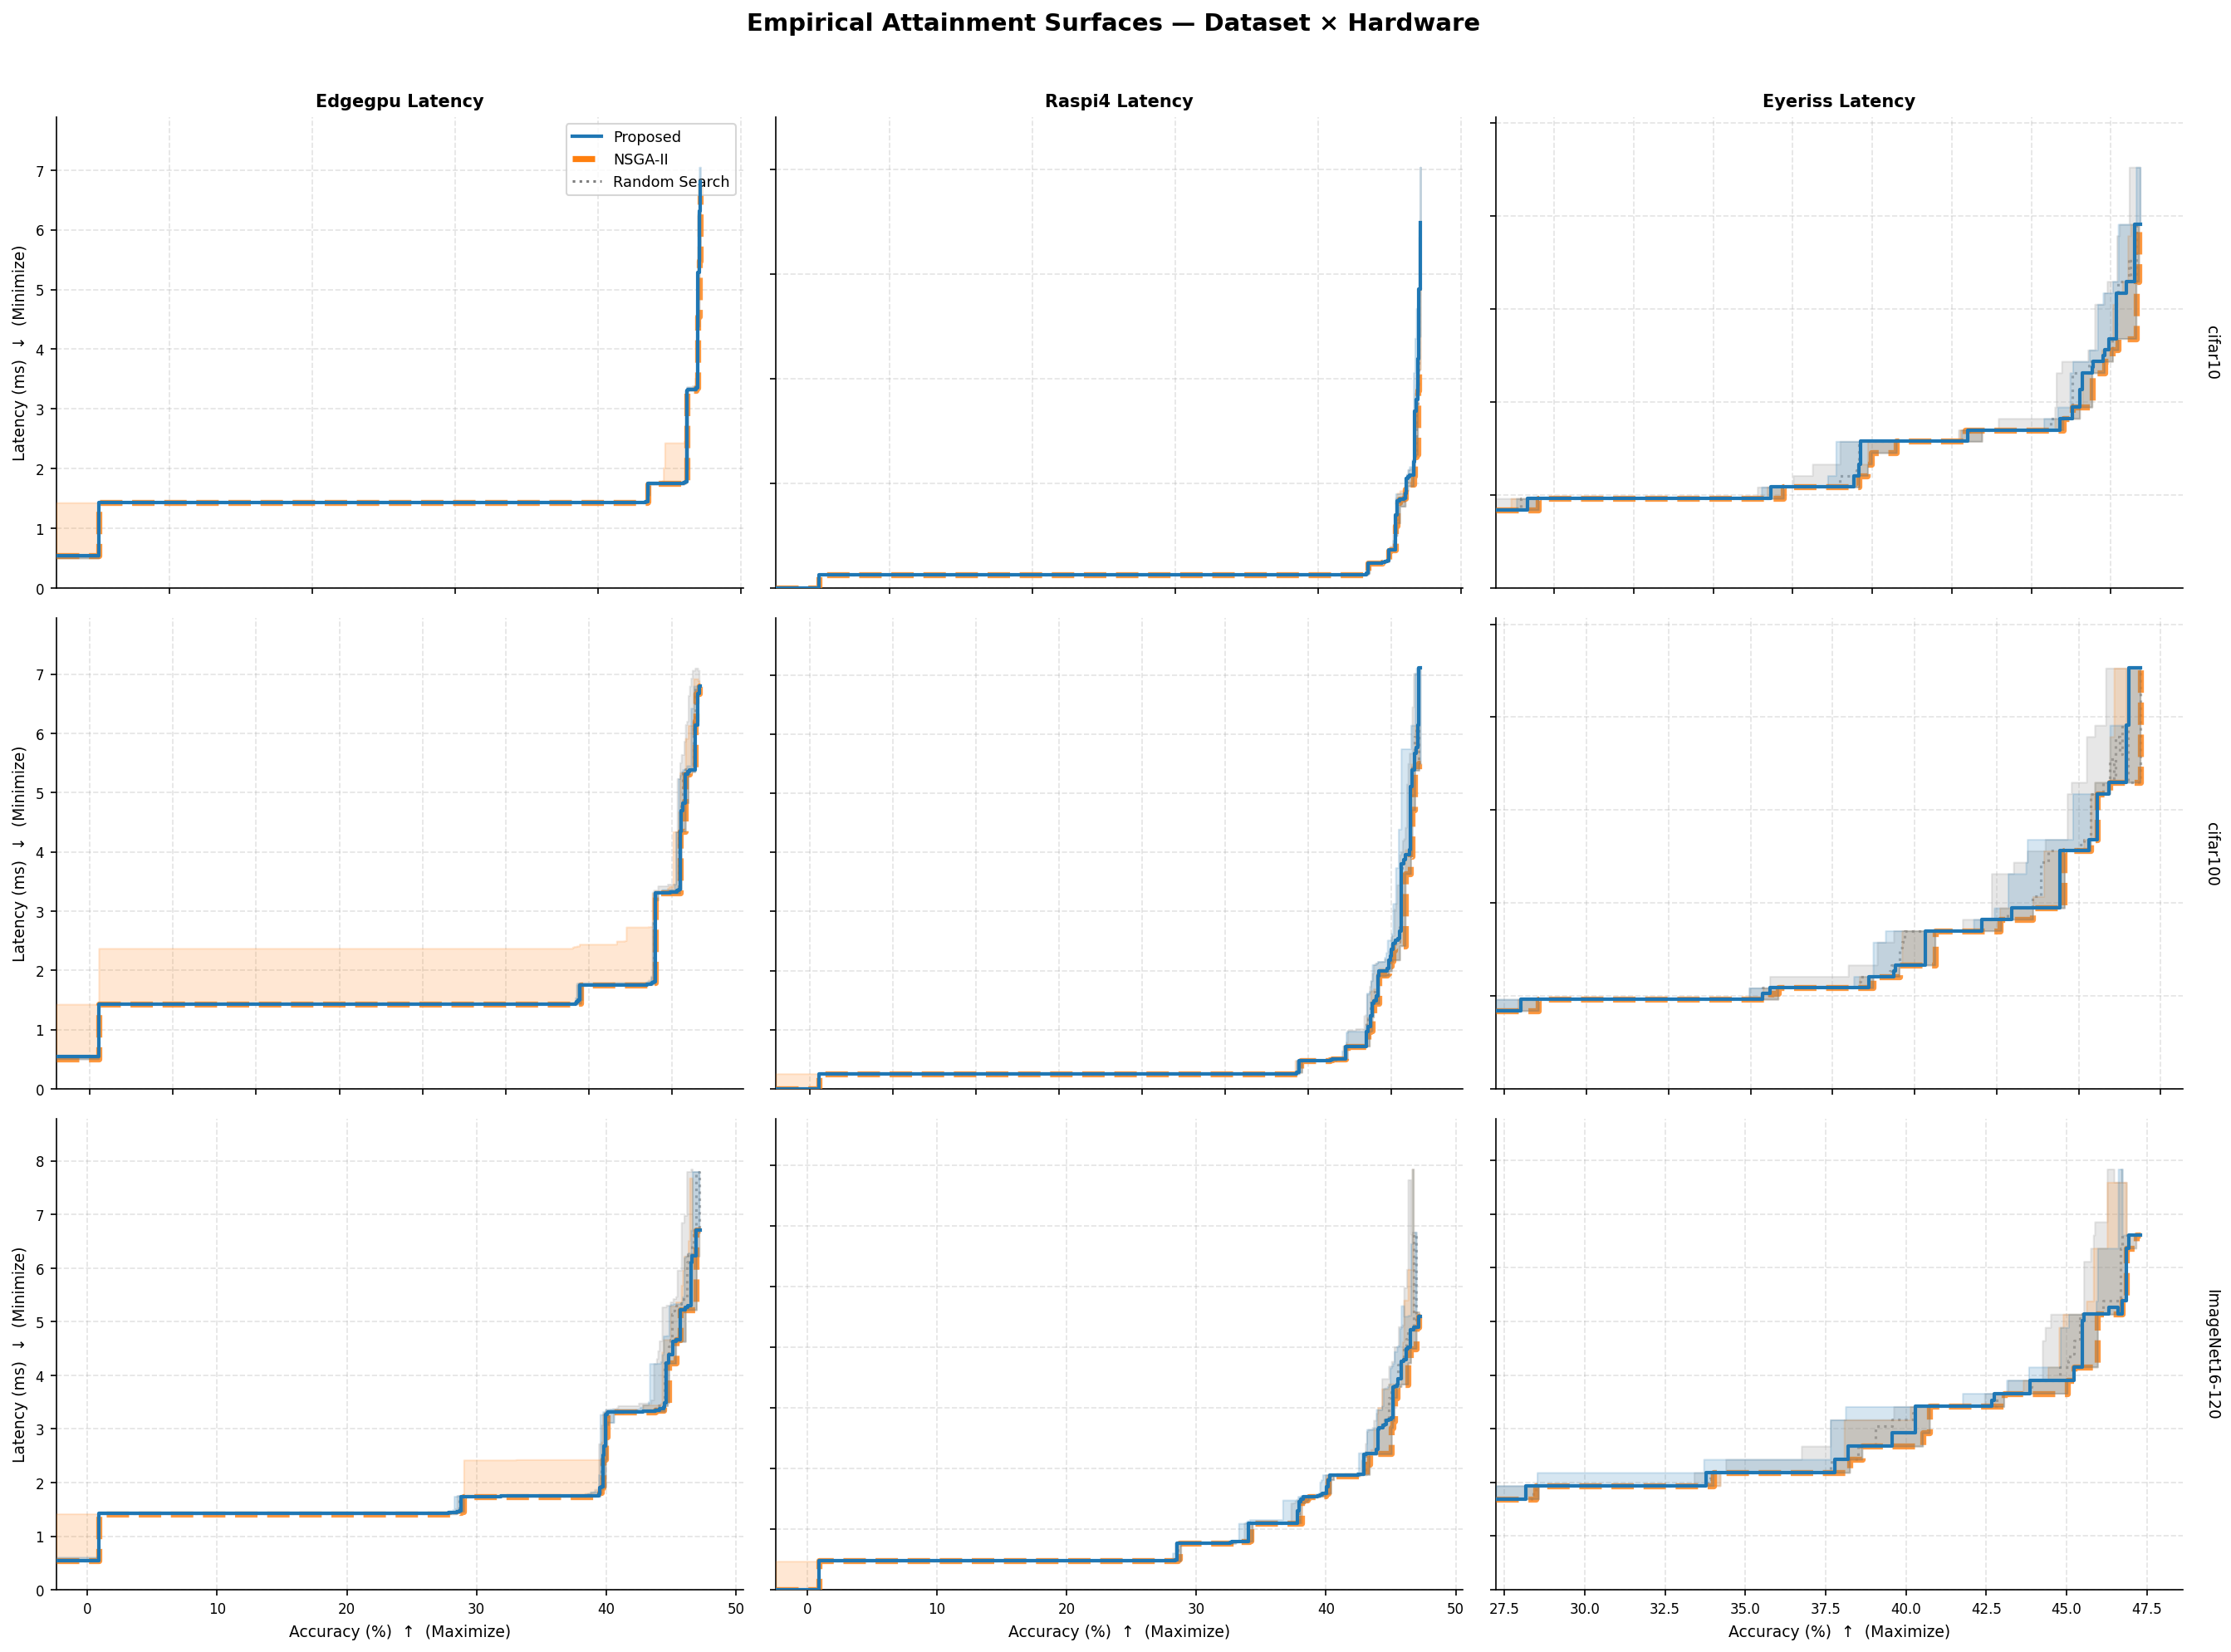

Saved EAF grid → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/pareto_fronts/eaf_master_grid.pdf


In [6]:
# ── Empirical Attainment Surface (EAF) — 3×3 grid ────────────────────────────
# seed_front() and attained_latency() are imported from src.utils.pareto_math.
# Shaded band = best/worst seed range;  thick line = median across all seeds.

eaf_fig, eaf_axes = plt.subplots(
    nrows=len(DATASETS), ncols=len(HARDWARE),
    figsize=(6 * len(HARDWARE), 4.5 * len(DATASETS)),
)

for row_idx, dataset in enumerate(DATASETS):
    for col_idx, hardware in enumerate(HARDWARE):
        ax = eaf_axes[row_idx][col_idx]
        sets = combo_archive_sets(dataset, hardware)

        if all(len(v) == 0 for v in sets.values()):
            ax.text(0.5, 0.5, f"No data\n{dataset}/{hardware}",
                    ha="center", va="center", transform=ax.transAxes, color="grey")
            ax.set_xticks([]); ax.set_yticks([])
            continue

        x_lo, x_hi, y_hi = focus_range(sets)
        x_grid = np.linspace(x_lo, x_hi, 500)

        max_lat = 0.0
        legend_handles = []

        for algo in PLOT_ORDER:
            archives = sets.get(algo, [])
            if not archives:
                continue
            color, ls, _mk, lw, zo, al = ALGO_STYLES[algo]

            seed_lats = []
            for archive in archives:
                sf = seed_front(archive)
                if len(sf):
                    seed_lats.append(attained_latency(sf, x_grid))

            if not seed_lats:
                continue

            seed_lats = np.array(seed_lats)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                best   = np.nanmin(seed_lats,    axis=0)
                worst  = np.nanmax(seed_lats,    axis=0)
                median = np.nanmedian(seed_lats, axis=0)

            valid = ~np.isnan(median)
            if not valid.any():
                continue

            max_lat = max(max_lat, float(np.nanmax(worst)))
            ax.fill_between(x_grid[valid], best[valid], worst[valid],
                            color=color, alpha=0.18, step='post', zorder=zo - 1)
            ax.step(x_grid[valid], median[valid], where='post',
                    color=color, linestyle=ls, linewidth=lw, alpha=al, zorder=zo)
            legend_handles.append(
                mlines.Line2D([], [], color=color, linestyle=ls, linewidth=lw, label=algo)
            )

        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(0, max(max_lat * 1.12, 1.0))
        ax.tick_params(labelsize=8)

        if row_idx == len(DATASETS) - 1:
            ax.set_xlabel("Accuracy (%)  ↑  (Maximize)", fontsize=9)
        else:
            ax.set_xticklabels([])
        if col_idx == 0:
            ax.set_ylabel("Latency (ms)  ↓  (Minimize)", fontsize=9)
        else:
            ax.set_yticklabels([])
        if row_idx == 0:
            ax.set_title(hardware.replace("_", " ").title(), fontweight="bold", fontsize=10)
        if col_idx == len(HARDWARE) - 1:
            ax.annotate(dataset, xy=(1.03, 0.5), xycoords='axes fraction',
                        rotation=-90, ha='left', va='center', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.35)

        if row_idx == 0 and col_idx == 0 and legend_handles:
            ax.legend(handles=legend_handles[::-1], frameon=True,
                      fontsize=8.5, loc="upper right")

eaf_fig.suptitle("Empirical Attainment Surfaces — Dataset × Hardware",
                 fontsize=14, fontweight='bold')
eaf_fig.tight_layout(rect=[0, 0.0, 1, 0.97])
eaf_out = PLOTS_DIR / "eaf_master_grid.pdf"
eaf_fig.savefig(eaf_out, bbox_inches='tight', dpi=200)
plt.show()
print(f"Saved EAF grid → {eaf_out}")

